In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容, get_end_word, add_next_sentence
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def find_评估标准_rule_base(docs):
    logging.getLogger().setLevel(logging.ERROR)
    
    # We first define the keywords we want to search
    keywords = ["自评","巡查","监督","检查","追究","考核"]
    pattern = re.compile('|'.join(keywords))
    
    # We also define the fuzzy keywords we want to search
    keywords_fuzzy = ["责任追究","尽职免责","领导巡查","提交报告"]
    
    # We define the pattern we want to search for the "章节" information
    keywords_章节 = ["(?:^|,)\s*第.*?(章|节|点|条).*?(绩效检查|监督检查|监督管理|监督|绩效|评估|评价|考核|自评)"]
    pattern_章节 = re.compile('|'.join(keywords_章节))
    
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    
    i = 0
    while i < len(paragraphs):
        paragraph = paragraphs[i]
        
        # if we find the "章节" relative information
        if pattern_章节.search(paragraph):
            match = pattern_章节.search(paragraph)
            temp = []
            temp += [paragraph]
            
            number_pattern = re.compile(r'\d+')
            number_chinese_pattern = re.compile(r'(?:(?:[一二三四五六七八九]十)?[一二三四五六七八九]|十[一二三四五六七八九]?|二十|三十|四十|五十|六十|七十|八十|九十)')
            
            # In this function, we detect the "章节" information, for example, 第一章
            end_word = get_end_word(paragraph, number_pattern, number_chinese_pattern)
            
            # if we successfully find the end word, such as 第二章。Now we will retrieve the content between 第一章 and 第二章
            if end_word:
                reach_end = True
                
                # We first add all the content between 第一章 and 第二章
                i += 1
                while i < len(paragraphs) and reach_end:
                    if end_word in paragraphs[i]:
                        reach_end = False
                        break
                    temp += [paragraphs[i]]
                    i += 1
                
                # If end word is indeed in following paragraphs, we add the content between 第一章 and 第二章
                if reach_end == False:
                    for index, sentence in enumerate(temp):
                        if index == 0:
                            matched_paragraphs.append((sentence, match.group()))
                        else:
                            matched_paragraphs.append((sentence, "章节/条款内容"))
                
                # If end word is not in following paragraphs, we add the content between 第一章 and the next sentence
                else:
                    next_index = paragraphs.index(paragraph) + 1
                    matched_paragraphs = add_next_sentence(paragraphs, paragraph, next_index, matched_paragraphs, match, "章节/条款内容")
                    
                    # We reset the index to the next sentence index, so we can continue our while loop
                    i = next_index
                    
            # no end word, we add the content between 第一章 and the next sentence
            else:
                next_index = paragraphs.index(paragraph) + 1
                matched_paragraphs = add_next_sentence(paragraphs, paragraph, next_index, matched_paragraphs, match, "章节/条款内容")
                
                # We reset the index to the next sentence index, so we can continue our while loop
                i = next_index
            
        elif pattern.search(paragraph):
            matched_paragraphs.append((paragraph.strip(), pattern.search(paragraph).group()))
        elif process.extractOne(paragraph, keywords_fuzzy)[1] >= 60:
                matched_paragraphs.append((paragraph.strip(), process.extractOne(paragraph, keywords_fuzzy)[0]))   
            
        i += 1
            
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index


## Demonstration for using find_评估标准_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[20]
docs = open(f'sample/{file_sample}', 'r').read()
matched_paragraphs, matched_paragraphs_index = find_评估标准_rule_base(docs)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [5]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
# display all rows
pd.set_option('display.max_rows', None)
df.head(10)

,Retrieve Info,Reason
0,第三条 临时机构财务管理的主要内容包括收入管理、支出管理、资产管理、债务管理、财务监督等,第三条 临时机构财务管理的主要内容包括收入管理、支出管理、资产管理、债务管理、财务监督
1,应当明确经济业务事项和会计事项的审批人员、记账人员、经办人员、财物保管人员的职责权限，并建立相互分离、相互制约的监督制度,监督
2,第九条 临时机构应建立健全资产管理制度，明确资产管理使用责任,责任追究
3,第十三条 市财政、审计部门要加强对临时机构财务的管理监督，加强财政资金的跟踪问效，切实确保资金安全，提高资金使用效益,第十三条 市财政、审计部门要加强对临时机构财务的管理监督


$\textbf{We can also check where is the sentence}$

In [6]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.879103
原文链接：https://www.pkulaw.com/lar/a1bfc9b241212a93e43c9a20cdb8386abdfb.html
随州市人民政府办公室关于印发随州市市级临时机构财务管理暂行办法的通知
随州市人民政府办公室关于印发随州市市级临时机构财务管理暂行办法的通知

各县、市、区人民政府，经济开发区、大洪山风景名胜区管理委员会，市政府各部门：

　　《随州市市级临时机构财务管理暂行办法》已经市人民政府同意，现印发给你们，请遵照执行。
　　2013年2月27日
　　随州市市级临时机构财务管理暂行办法
　　第一条　为规范市级临时机构财务管理，确保国家资金、财产安全，根据《会计法》及有关财经法律法规，结合实际，特制定本办法。
　　第二条　市级临时机构是指在一定时期内执行某一特定工作任务或项目，经市委、市政府批准成立的机构。具体包括各类领导小组、协调小组、组委会、指挥部等。
　　第三条　临时机构财务管理的主要内容包括收入管理、支出管理、资产管理、债务管理、财务监督等。
　　第四条　临时机构财务活动在该机构负责人领导下，由其财务部门统一管理。财务活动坚持临时机构负责人“一支笔”审批的原则，即机构负责人负责具体审批事项，对本机构的财务活动负全面责任。
　　第五条　临时机构应按照财务会计制度的要求，建立健全财务管理制度和内部控制制度，配备持有会计从业资格证书的会计人员。应当明确经济业务事项和会计事项的审批人员、记账人员、经办人员、财物保管人员的职责权限，并建立相互分离、相互制约的监督制度。
　　第六条　临时机构应按规定建立健全账目，统一核算管理财务收支活动。开设银行账户必须报市财政局审批。
　　第七条　临时机构收入实行“收支两条线”管理，所有收入应及时足额缴存财政专户，不得坐收坐支，以支抵收，严禁私设“小金库”，支出纳入国库集中支付管理。
　　第八条　临时机构支出应严格遵守有关财政财务制度及财经纪律。各项工程必须实行公开招投标制和预决算制度，工程结束后，必须报经审计机关基本建设工程竣工决算审计。工作经费必须实行预算管理，严格控制支出范围和支出标准，从严控制接待费、办公费、车修费等支出。
　　第九条　临时机构应建立健全资产管理制度，明确资产管理使用责任。购置资产应按必需、节约、有效的原则，实行政府采购，建立固

## Now we can run batch processing on our sample data ##

In [7]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['File Name', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        matched_paragraphs, matched_paragraphs_index = find_评估标准_rule_base(docs)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list)]
    
    return return_df


In [8]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length
0,吉林保监局关于安邦人寿保险股份有限公司吉林...(FBM-CLI.12.1776690).txt,,,485,0
1,北京市人民政府办公厅印发《关于在“十三五”...(FBM-CLI.12.1250419).txt,（一）加强组织领导\n（四）严格监督检查\n开展精准救助逐级督查，选择重点区、重点街道（乡镇）进行重点督查，对政策落实不力的要追究相关单位和人员责任\n完善社会救助资金监督管理机制，定期组织财政、审计、监察等部门开展救助资金监督检查，最大限度防范资金风险,领导巡查\n监督\n追究\n监督,4421,124
2,山西省林业和草原局关于印发《退耕还林还草作...(FBM-CLI.12.4108330).txt,4.退耕还林工程档案是检查验收和国家政策兑现的直接依据，各地要建立健全档案管理制度，做到专人专柜，充分利用信息系统进行档案管理，以确保工程档案的完整、准确与系统,检查,805,80
3,北京市教育委员会、北京市经济和信息化局、北...(FBM-CLI.12.4087809).txt,,,480,0
4,吕梁市住房保障和城乡建设管理局关于转发山西...(FBM-CLI.12.1887683).txt,吕梁市住房保障和城乡建设管理局关于转发山西省住房和城乡建设厅《关于开展2012年度建筑业等5类企业动态考核评价工作的通知》的通知\n吕梁市住房保障和城乡建设管理局关于转发山西省住房和城乡建设厅《关于开展2012年度建筑业等5类企业动态考核评价工作的通知》的通知\n现将省住建厅晋建市字【2012】289号“山西省住房和城乡建设厅关于开展2012年度建筑业等5类企业动态考核评价工作的通知”转发给你们，建筑业一级、二级及设计施工一体化企业，监理企业，招标代理企业请遵照执行\n附件：山西省住房和城乡建设厅关于开展2012年度建筑业等5类企业动态考核评价工作的通知（晋建市字〔2012〕289号）（略）,考核\n考核\n考核\n考核,499,296


$\textbf{Here we provide some statistics on the results}$

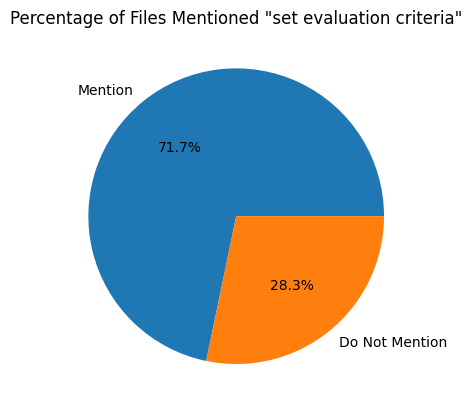

In [9]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "set evaluation criteria"')
plt.show()

$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

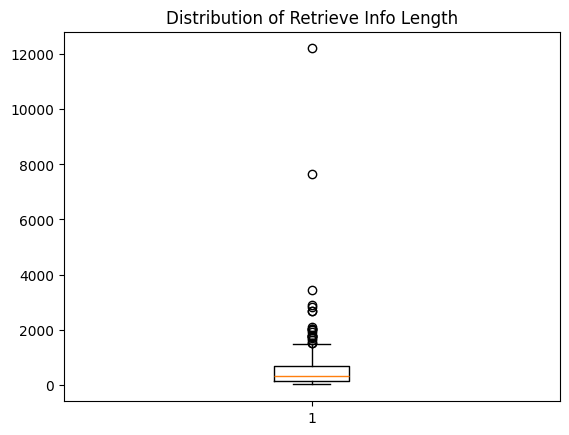

In [10]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

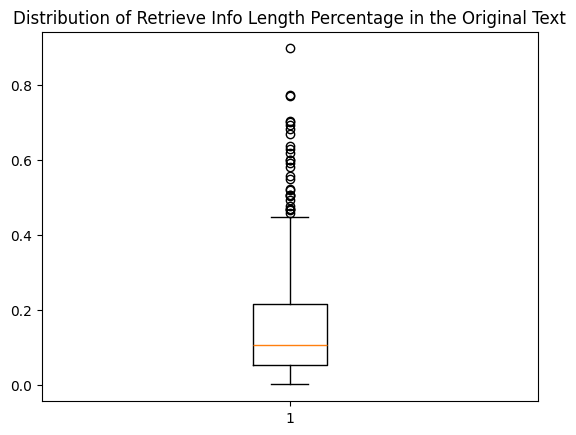

In [11]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [12]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

File Name  \
171  绵阳市人民政府关于印发绵阳市推行“证照分离...(FBM-CLI.12.4807696).txt   
98         成都市环卫清扫保洁精细化监督管理办法(FBM-CLI.12.5538971).txt   
379  南昌市教育局、南昌市市场监督管理局、南昌市...(FBM-CLI.12.5677580).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [13]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

File Name  \
98         成都市环卫清扫保洁精细化监督管理办法(FBM-CLI.12.5538971).txt   
445  甘肃省环境保护厅关于组织开展省内环境影响评...(FBM-CLI.12.1737752).txt   
297  云南省食品药品监督管理局关于省内国产非特殊...(FBM-CLI.12.1200381).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

## We can also comparing the statistics results between two different labels ##

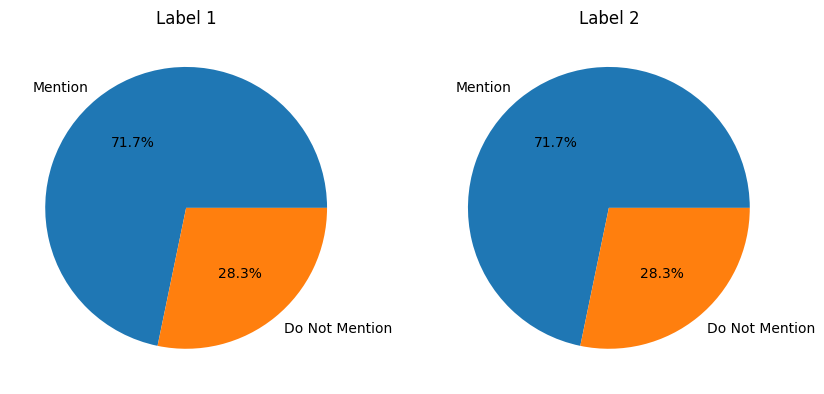

In [14]:
# To achieve this comparison, we need to folder to store the policy data for two labels respectively
# To avoid the relative path issue, We use absolute path here
path_to_folder_label1 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'
path_to_folder_label2 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'

df_label1 = run_batch(path_to_folder_label1)
df_label2 = run_batch(path_to_folder_label2)

# compare two bar chart
is_mention_label1 = len(df_label1[df_label1['Retrieve Info'] != ''])
do_not_mention_label1 = len(df_label1[df_label1['Retrieve Info'] == ''])
is_mention_label2 = len(df_label2[df_label2['Retrieve Info'] != ''])
do_not_mention_label2 = len(df_label2[df_label2['Retrieve Info'] == ''])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].pie([is_mention_label1, do_not_mention_label1], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[0].set_title('Label 1')
ax[1].pie([is_mention_label2, do_not_mention_label2], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[1].set_title('Label 2')
plt.show()

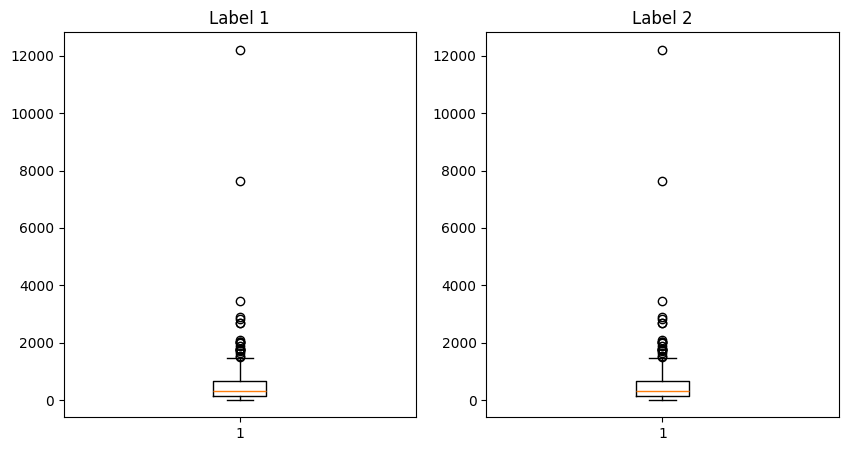

In [15]:
# We can also compare the distribution of retrieve info length
df_label1 = df_label1[df_label1['Retrieve Info'] != '']
df_label2 = df_label2[df_label2['Retrieve Info'] != '']

retrieve_info_length_label1 = df_label1['Retrieve Info'].apply(lambda x: len(x))
retrieve_info_length_label2 = df_label2['Retrieve Info'].apply(lambda x: len(x))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(retrieve_info_length_label1)
ax[0].set_title('Label 1')
ax[1].boxplot(retrieve_info_length_label2)
ax[1].set_title('Label 2')
plt.show()

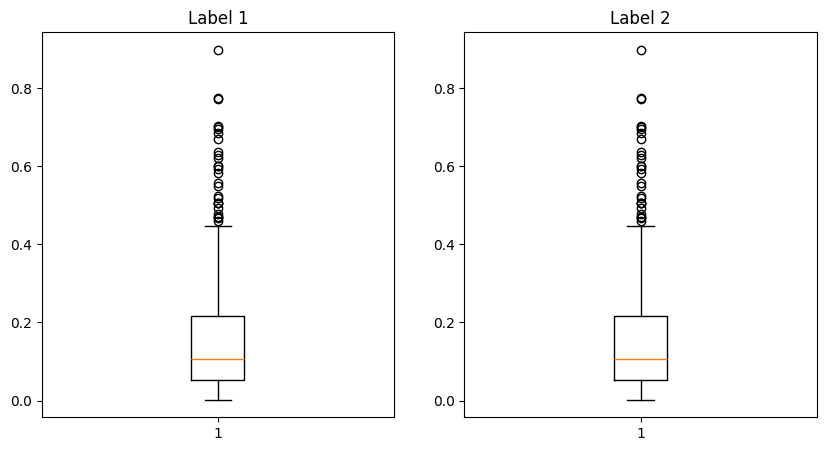

In [16]:
df_label1['Retrieve Info Length Percentage'] = df_label1['Retrieve Info Length'] / df_label1['Original Text Length']
df_label2['Retrieve Info Length Percentage'] = df_label2['Retrieve Info Length'] / df_label2['Original Text Length']

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(df_label1['Retrieve Info Length Percentage'])
ax[0].set_title('Label 1')
ax[1].boxplot(df_label2['Retrieve Info Length Percentage'])
ax[1].set_title('Label 2')
plt.show()